# MPI Scaling Test Analysis — BSNSQ_SCALING

Parses profiling output files produced by `bsnsq_scaling_exec`, extracts per-call
timings for each labelled timer across all NPROCS runs, computes derived metrics,
and visualises parallel scaling performance.

## 1. Import Required Libraries

In [10]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## 2. Parse Profiling Data from Output File

Set `OUTPUT_FILE` to the path of the SLURM output file.  
The parser locates every `>>> SCALING TEST: NPROCS = N` header and the
`PROFILING TIMER REPORT` block that follows it.

In [11]:
# ── User configuration ────────────────────────────────────────────────────────
OUTPUT_FILE = '../../bsnsq_scaling.o15441897'   # path relative to this notebook
# ──────────────────────────────────────────────────────────────────────────────

# Compiled patterns
RE_NPROCS   = re.compile(r'>>>\s+SCALING TEST:\s+NPROCS\s*=\s*(\d+)')
RE_ROW      = re.compile(
    r'^\s*\d+\s+'          # IDX
    r'(\S+)\s+'            # LABEL  (no spaces in any label used)
    r'\d+\s+'              # COUNT
    r'[\d.]+\s+'           # TOTAL (s)
    r'([\d.]+)'            # PER-CALL (s)
)
RE_SEP      = re.compile(r'^={10,}')   # ============... separator line
RE_HEADER   = re.compile(r'^={70,}')   # Header separator line (longer than the regular separator)

records = []          # list of {nprocs, label, per_call_s}
current_nprocs = None
in_report = False

with open(OUTPUT_FILE, 'r') as fh:
    for line in fh:
        # Detect NPROCS header
        m = RE_NPROCS.search(line)
        if m:
            current_nprocs = int(m.group(1))
            print(f"Found NPROCS = {current_nprocs} at line: {line.strip()}")
            in_report = False
            continue

        # Detect start/end of profiling block
        if RE_SEP.match(line):
            if not in_report and not RE_HEADER.match(line):
                in_report = True   # opening separator
                if current_nprocs is not None:
                    print(f"Entering report block for NPROCS = {current_nprocs}")
            else:
                in_report = False  # closing separator
            continue

        if in_report and current_nprocs is not None:
            m = RE_ROW.match(line)
            if m:
                print(f"  Parsed timer: nprocs={current_nprocs}, label='{m.group(1).strip()}', per_call_s={m.group(2)}")
                records.append({
                    'nprocs':     current_nprocs,
                    'label':      m.group(1).strip(),
                    'per_call_s': float(m.group(2)),
                })

print(f"Parsed {len(records)} timer entries across "
      f"{len({r['nprocs'] for r in records})} NPROCS values.")
print("NPROCS found:", sorted({r['nprocs'] for r in records}))

Found NPROCS = 128 at line: >>> SCALING TEST: NPROCS = 128  (OMP_NUM_THREADS=1)
Entering report block for NPROCS = 128
  Parsed timer: nprocs=128, label='STEP_ETDAB_CN', per_call_s=0.136260
  Parsed timer: nprocs=128, label='NONLIN', per_call_s=0.076777
  Parsed timer: nprocs=128, label='NONLIN_COMP', per_call_s=0.002990
  Parsed timer: nprocs=128, label='NONLIN_TOFP', per_call_s=0.045997
  Parsed timer: nprocs=128, label='NONLIN_PROJ', per_call_s=0.018092
  Parsed timer: nprocs=128, label='RTRAN', per_call_s=0.008147
  Parsed timer: nprocs=128, label='LINEAR', per_call_s=0.005686
Found NPROCS = 64 at line: >>> SCALING TEST: NPROCS = 64  (OMP_NUM_THREADS=1)
Entering report block for NPROCS = 64
  Parsed timer: nprocs=64, label='STEP_ETDAB_CN', per_call_s=0.293472
  Parsed timer: nprocs=64, label='NONLIN', per_call_s=0.164148
  Parsed timer: nprocs=64, label='NONLIN_COMP', per_call_s=0.007039
  Parsed timer: nprocs=64, label='NONLIN_TOFP', per_call_s=0.101493
  Parsed timer: nprocs=64, 

## 3. Organize Raw Profiling Data into DataFrame

In [12]:
RAW_LABELS = [
    'STEP_ETDAB_CN', 'NONLIN', 'NONLIN_COMP',
    'NONLIN_TOFP', 'NONLIN_PROJ', 'RTRAN', 'LINEAR',
]

df_raw = (
    pd.DataFrame(records)
    .pivot_table(index='nprocs', columns='label', values='per_call_s', aggfunc='first')
    .sort_index()
)

# Keep only expected labels (drop any extras silently)
present = [l for l in RAW_LABELS if l in df_raw.columns]
df_raw = df_raw[present]

print("Raw per-call timings (seconds):\n")
print(df_raw.to_string(float_format=lambda x: f'{x:.6f}'))

Raw per-call timings (seconds):

label   STEP_ETDAB_CN   NONLIN  NONLIN_COMP  NONLIN_TOFP  NONLIN_PROJ    RTRAN   LINEAR
nprocs                                                                                 
2            2.349036 1.134957     0.020314     0.636962     0.274839 0.182197 0.123215
4            2.504893 1.583093     0.016987     1.026201     0.364885 0.093839 0.062060
8            1.605597 1.037787     0.016607     0.679729     0.231441 0.051452 0.032395
16           0.937032 0.563989     0.016717     0.352633     0.122184 0.034988 0.026187
32           0.634778 0.365844     0.015546     0.217457     0.078975 0.024943 0.021339
64           0.293472 0.164148     0.007039     0.101493     0.034272 0.015664 0.011390
128          0.136260 0.076777     0.002990     0.045997     0.018092 0.008147 0.005686


## 4. Compute Derived Timing Metrics

| Metric | Formula | Notes |
|---|---|---|
| `STEP_ETDAB_CN` | direct | whole time-step |
| `NONLIN_COMP` | direct | avg of 2 segments (GRAD + vector products) |
| `LINEAR` | direct | `CALC_BOUSSI_ETDAB_SUB` |
| `TOFP` | `NONLIN_TOFP / 9` | 9 TOFP calls per NONLIN (3 vel + 3 vor + 3 grad) |
| `RTRAN` | `RTRAN / 6` | 6 RTRAN calls measured together per step |
| `PROJ` | `NONLIN_PROJ − (TOFP − RTRAN) × 3` | removes 3 × PLNFFT cost, isolating the pure projection work |

`PLNFFT ≈ TOFP − RTRAN`: TOFP performs a radial transform (RTRAN) plus the
remaining azimuthal/axial FFT steps.  NONLIN_PROJ calls PLNFFT 3 times to
convert velocity from physical–Fourier–Fourier (PFF) space back to
poloidal–toroidal decomposition in FFF space.

In [13]:
r = df_raw   # shorthand

TOFP  = r['NONLIN_TOFP']  / 9
RTRAN = r['RTRAN']         / 6

df_metrics = pd.DataFrame({
    'STEP_ETDAB_CN': r['STEP_ETDAB_CN'],
    'NONLIN_COMP':   r['NONLIN_COMP'],
    'LINEAR':        r['LINEAR'],
    'TOFP':          TOFP,
    'RTRAN':         RTRAN,
    'PROJ':          r['NONLIN_PROJ'] - (TOFP - RTRAN) * 3,
}, index=r.index)

print("Derived timing metrics (per-call seconds):\n")
print(df_metrics.to_string(float_format=lambda x: f'{x:.6f}'))

# Sanity: PROJ should be positive everywhere
neg = df_metrics['PROJ'][df_metrics['PROJ'] < 0]
if not neg.empty:
    print(f"\n⚠  PROJ is negative for nprocs = {list(neg.index)} — check timer labels.")
else:
    print("\n✓  PROJ is non-negative for all measured NPROCS.")

Derived timing metrics (per-call seconds):

        STEP_ETDAB_CN  NONLIN_COMP   LINEAR     TOFP    RTRAN     PROJ
nprocs                                                                
2            2.349036     0.020314 0.123215 0.070774 0.030366 0.153617
4            2.504893     0.016987 0.062060 0.114022 0.015640 0.069738
8            1.605597     0.016607 0.032395 0.075525 0.008575 0.030591
16           0.937032     0.016717 0.026187 0.039181 0.005831 0.022134
32           0.634778     0.015546 0.021339 0.024162 0.004157 0.018961
64           0.293472     0.007039 0.011390 0.011277 0.002611 0.008273
128          0.136260     0.002990 0.005686 0.005111 0.001358 0.006833

✓  PROJ is non-negative for all measured NPROCS.


## 5. Visualize Scaling Performance

Log–log plot of per-step wall time vs. number of MPI processes.
The dashed grey line shows ideal (perfect) strong scaling: $T(p) = T(1)/p$.

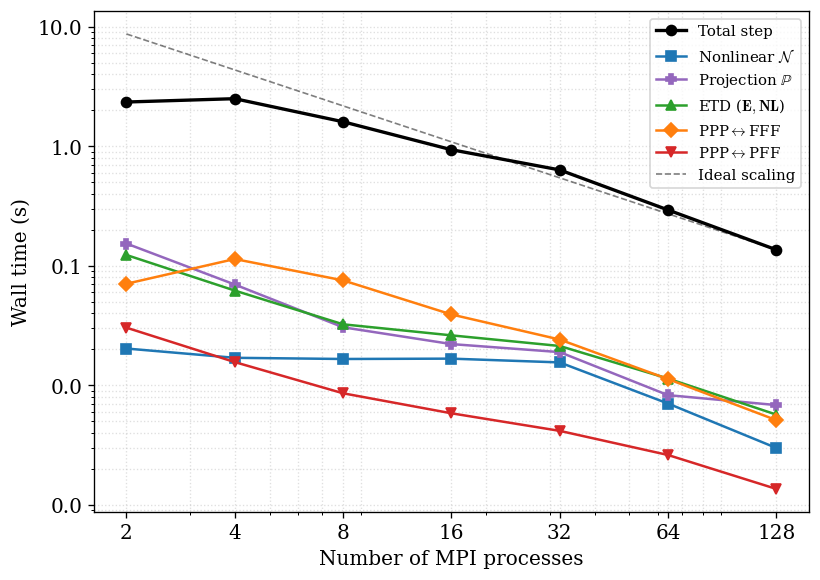

In [42]:
# METRIC_STYLE = {
#     'STEP_ETDAB_CN': dict(color='black',   marker='o', lw=2,   label='Tot'),
#     'NONLIN_COMP':   dict(color='tab:blue',  marker='s', lw=1.5, label='Nonlin (comp)'),
#     'LINEAR':        dict(color='tab:green', marker='^', lw=1.5, label='Lin (comp)'),
#     'TOFP':          dict(color='tab:orange',marker='D', lw=1.5, label='TOFP (single call)'),
#     'RTRAN':         dict(color='tab:red',   marker='v', lw=1.5, label='RTRAN (single call)'),
#     'PROJ':          dict(color='tab:purple',marker='P', lw=1.5, label='PROJ (single call)'),
# }

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# 1. Standard Matplotlib setup (Works on any system)
plt.rcParams.update({
    "text.usetex": False,          # Disable external LaTeX
    "font.family": "serif",        # Still uses a serif font for academic look
    "mathtext.fontset": "cm",      # Uses Computer Modern (LaTeX font) internally
    "font.size": 12
})

# 2. Update METRIC_STYLE with Mathtext-compatible labels
# Note: In mathtext, you don't escape underscores like \_, just use _
METRIC_STYLE = {
    'STEP_ETDAB_CN': dict(color='black',   marker='o', lw=2,   
                          label='Total step'),
    'NONLIN_COMP':   dict(color='tab:blue',  marker='s', lw=1.5, 
                          label=r'Nonlinear $\mathcal{N}$'),
    'PROJ':          dict(color='tab:purple',marker='P', lw=1.5, 
                          label=r'Projection $\mathbb{P}$'),
    'LINEAR':        dict(color='tab:green', marker='^', lw=1.5, 
                          label=r'ETD ($\mathbf{E}, \mathbf{NL}$)'),
    'TOFP':          dict(color='tab:orange',marker='D', lw=1.5, 
                          label=r'PPP$\leftrightarrow$FFF'),
    'RTRAN':         dict(color='tab:red',   marker='v', lw=1.5, 
                          label=r'PPP$\leftrightarrow$PFF'),
}

nprocs = df_metrics.index.values
fig, ax = plt.subplots(figsize=(7, 5))

# Reference ideal scaling anchored at the largest nprocs / smallest time
ref_nprocs = np.geomspace(nprocs.min(), nprocs.max(), 200)

for metric, style in METRIC_STYLE.items():
    if metric not in df_metrics.columns:
        continue
    T = df_metrics[metric].values
    ax.loglog(nprocs, T, **style)

# Ideal line anchored on STEP_ETDAB_CN at max nprocs
T_ref = df_metrics['STEP_ETDAB_CN'].iloc[-1]   # largest nprocs (last row)
p_ref = nprocs[-1]
ax.loglog(ref_nprocs, T_ref * p_ref / ref_nprocs,
          'k--', lw=1, alpha=0.5, label='Ideal scaling')

ax.set_xlabel('Number of MPI processes')
ax.set_ylabel('Wall time (s)')
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks(nprocs)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, which='both', ls=':', alpha=0.4)
plt.tight_layout()
plt.savefig('./strong_scaling_results.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

## 6. Compute Speedup and Parallel Efficiency

$$S(p) = \frac{T(1)}{T(p)}, \qquad E(p) = \frac{S(p)}{p}$$

If NPROCS = 1 is not present in the data the minimum measured NPROCS is used
as the serial baseline.

Baseline nprocs = 2

Speedup S(p) = T(1) / T(p):

        STEP_ETDAB_CN  NONLIN_COMP  LINEAR   TOFP  RTRAN   PROJ
nprocs                                                         
2               1.000        1.000   1.000  1.000  1.000  1.000
4               0.938        1.196   1.985  0.621  1.942  2.203
8               1.463        1.223   3.804  0.937  3.541  5.022
16              2.507        1.215   4.705  1.806  5.207  6.940
32              3.701        1.307   5.774  2.929  7.305  8.102
64              8.004        2.886  10.818  6.276 11.632 18.568
128            17.239        6.794  21.670 13.848 22.364 22.481

Parallel efficiency E(p) = S(p) / p:

        STEP_ETDAB_CN  NONLIN_COMP  LINEAR  TOFP  RTRAN  PROJ
nprocs                                                       
2               0.500        0.500   0.500 0.500  0.500 0.500
4               0.234        0.299   0.496 0.155  0.485 0.551
8               0.183        0.153   0.475 0.117  0.443 0.628
16              0.157    

/tmp/ipykernel_4120981/2966971480.py:41: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax_e.set_ylim(0, 1.2)


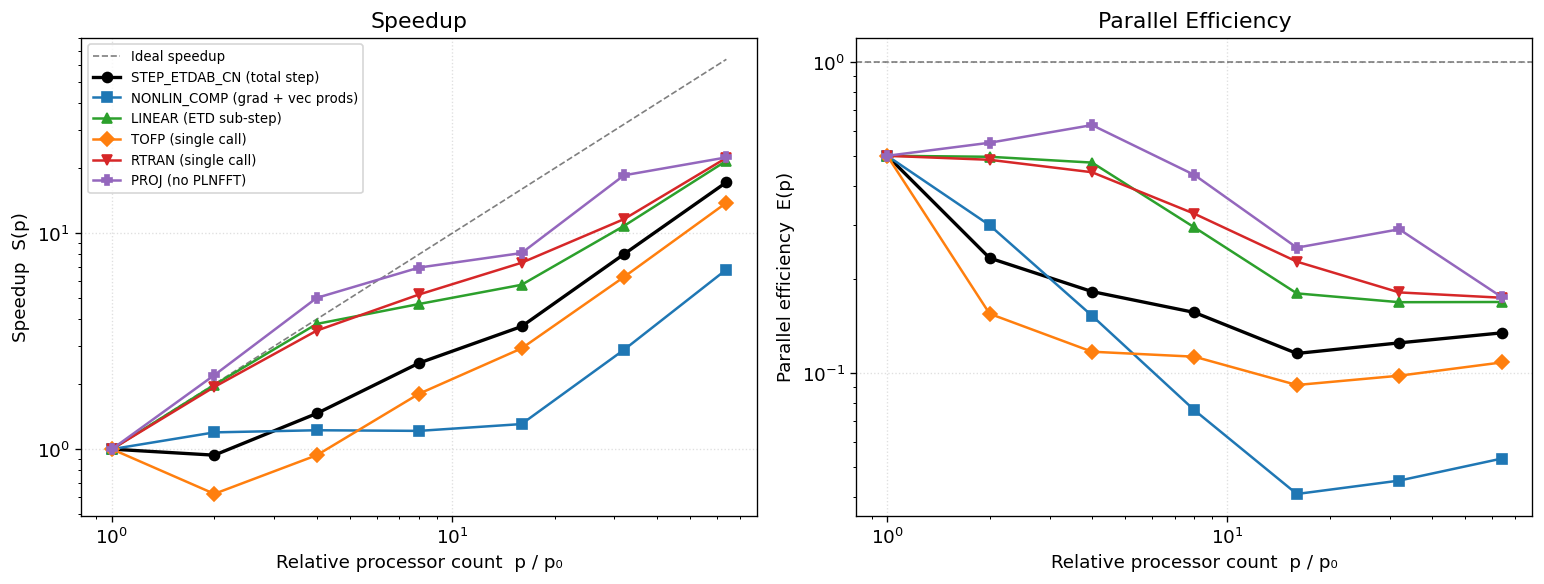

In [15]:
# Serial baseline: prefer nprocs=1, fall back to minimum available
baseline_p = 1 if 1 in df_metrics.index else df_metrics.index.min()
T_serial = df_metrics.loc[baseline_p]
print(f"Baseline nprocs = {baseline_p}")

df_speedup = df_metrics.apply(lambda col: T_serial[col.name] / col)
df_efficiency = df_speedup.apply(lambda col: col / df_metrics.index.to_series().values)

print("\nSpeedup S(p) = T(1) / T(p):\n")
print(df_speedup.to_string(float_format=lambda x: f'{x:.3f}'))
print("\nParallel efficiency E(p) = S(p) / p:\n")
print(df_efficiency.to_string(float_format=lambda x: f'{x:.3f}'))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax_s, ax_e = axes

# Ideal speedup
ax_s.loglog(nprocs / baseline_p, nprocs / baseline_p,
          'k--', lw=1, alpha=0.5, label='Ideal speedup')
ax_e.axhline(1.0, color='k', ls='--', lw=1, alpha=0.5, label='Ideal efficiency')

for metric, style in METRIC_STYLE.items():
    if metric not in df_speedup.columns:
        continue
    kw = {k: v for k, v in style.items()}   # copy
    ax_s.loglog(nprocs / baseline_p, df_speedup[metric].values,  **kw)
    kw2 = dict(kw); kw2.pop('label', None)
    ax_e.loglog(nprocs / baseline_p, df_efficiency[metric].values, **kw2)

ax_s.set_xlabel('Relative processor count  p / p₀')
ax_s.set_ylabel('Speedup  S(p)')
ax_s.set_title('Speedup')
ax_s.legend(fontsize=8)
ax_s.grid(True, ls=':', alpha=0.4)

ax_e.set_xlabel('Relative processor count  p / p₀')
ax_e.set_ylabel('Parallel efficiency  E(p)')
ax_e.set_title('Parallel Efficiency')
ax_e.set_ylim(0, 1.2)
ax_e.grid(True, ls=':', alpha=0.4)

plt.tight_layout()
plt.show()